# FPM SIMULATION


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
#from scipy.fft import fft2, ifft2, fftshift, ifftshift

##### Defining Parameters

In [71]:
# Illumination & Setup
wavelength = 532e-9        # LED wavelength (m)
array_size = 7             # 7x7 LED array
led_pitch = 4e-3           # 4mm spacing between LEDs
z_led = 60e-3              # 60mm distance from LED to sample

# Objective Lens & Camera
NA = 0.08                  # Objective Numerical Aperture
mag = 2.0                  # Magnification
pixel_size = 6.5e-3        # Typical sCMOS camera pixel size (m)
pixel_size_eff = pixel_size / mag      # Effective pixel size at the object plane (3.25 um)

# Grid Sizes (Powers of 2 for efficient FFT)
N_LR = 128                 # Low-Res image dimensions (64x64)
ds = 4                     # Upsampling factor for High-Res reconstruction
N_HR = N_LR * ds           # High-Res object dimensions (256x256)
pixel_size_HR = pixel_size_eff / ds     # High-Res pixel size (0.8125 um)

# Defocus Parameter
z_defocus = 0.150          # Sample is defocused by 150 um (0.15 mm)

##### GROUND TRUTH OBJECT

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

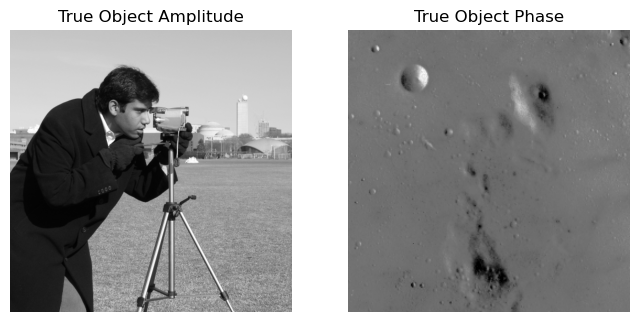

In [72]:
# Amplitude: Cameraman, Phase: Moon
amp = transform.resize(data.camera(), (N_HR, N_HR), anti_aliasing=True) 
#anti_aliasing=True applies a Gaussian smoothing filter before resampling, which helps produce smoother results.
amp = amp / amp.max()                                #Normalization

phase = transform.resize(data.moon(), (N_HR, N_HR), anti_aliasing=True)
phase = (phase / phase.max()) * np.pi # - (np.pi/2)    # Scale phase between -pi/2 and pi/2

obj_true = amp * np.exp(1j * phase)
obj_true_fourier = np.fft.fftshift(np.fft.fft2(obj_true))
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    
axs[0].imshow(np.abs(obj_true), cmap='gray')
axs[0].set_title('True Object Amplitude')
axs[0].axis('off')

axs[1].imshow(np.angle(obj_true), cmap='gray')
axs[1].set_title('True Object Phase')
axs[1].axis('off')

##### PUPIL FUNCTION (Low-Pass Filter)

Cutoff frequency =  150375.93984962406


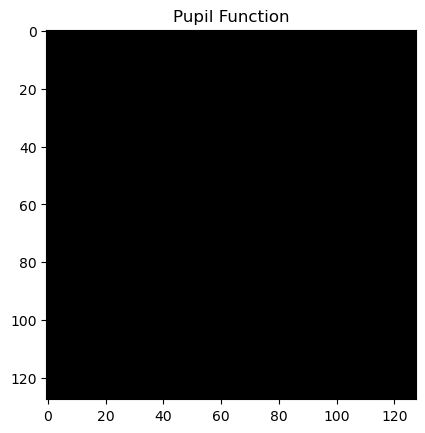

In [73]:
# The pupil acts as a low-pass filter in the Fourier domain
# np.fft.fftfreq(n, d); n = number of samples, d = sample spacing
fx_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=pixel_size_eff))
fy_LR = np.fft.fftshift(np.fft.fftfreq(N_LR, d=pixel_size_eff))
FX_LR, FY_LR = np.meshgrid(fx_LR, fy_LR)

cutoff_freq = NA / wavelength
print('Cutoff frequency = ',cutoff_freq)
pupil = (FX_LR**2 + FY_LR**2 <= cutoff_freq**2).astype(float)

plt.figure()
plt.imshow(pupil, cmap='gray')
plt.title('Pupil Function')
plt.show()

In [74]:
 # Aberrated Pupil (includes defocus phase factor)
# The phase factor is e^(i * z * k_z) where k_z = 2*pi*sqrt((1/lambda)^2 - fx^2 - fy^2)
phase_prop = np.maximum((1/wavelength)**2 - FX_LR**2 - FY_LR**2, 0)
kz = 2 * np.pi * np.sqrt(phase_prop)
defocus_phase = z_defocus * kz

# The generalized pupil function includes the physical aberration
pupil_aberrated = pupil * np.exp(1j * defocus_phase)

##### LED array Visualization

Text(0, 0.5, 'Positions of LED (in metres)')

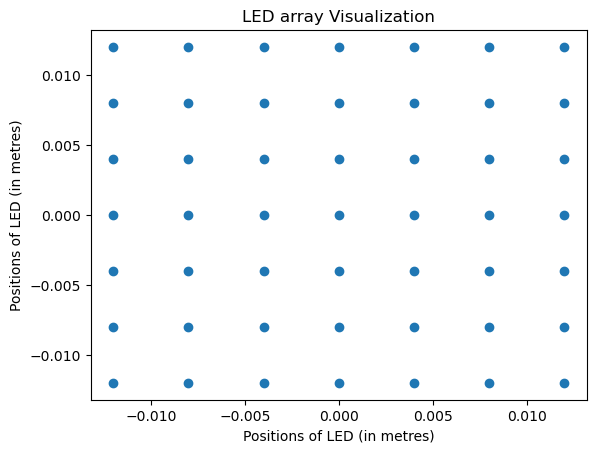

In [75]:
# Calculate LED positions
led_idx = np.arange(array_size) - (array_size)// 2
x_led, y_led = np.meshgrid(led_idx * led_pitch, led_idx * led_pitch)

plt.scatter(x_led,y_led)
plt.title('LED array Visualization')
plt.xlabel('Positions of LED (in metres)')
plt.ylabel('Positions of LED (in metres)')

##### FORWARD MODEL (Simulating LR Captures)

C:\Users\gaura\AppData\Local\Temp\ipykernel_12620\2209668969.py:50: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 2, figsize=(6, 3))


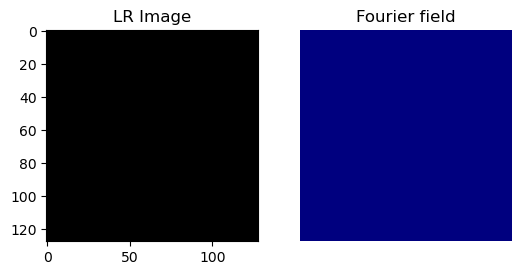

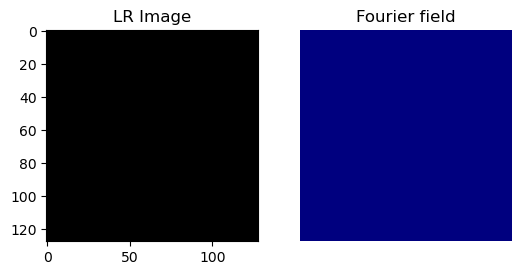

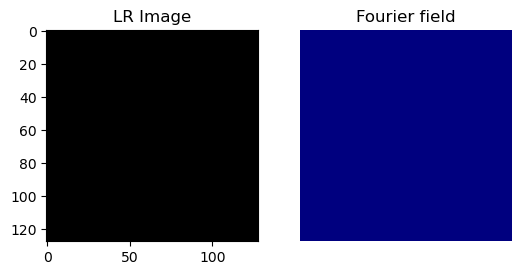

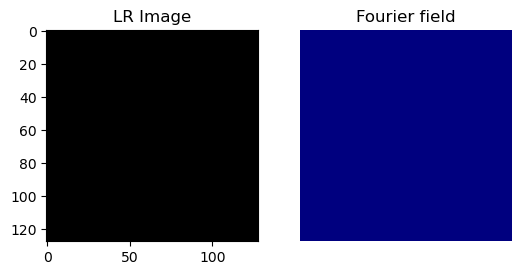

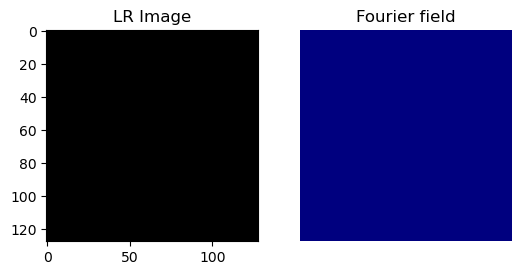

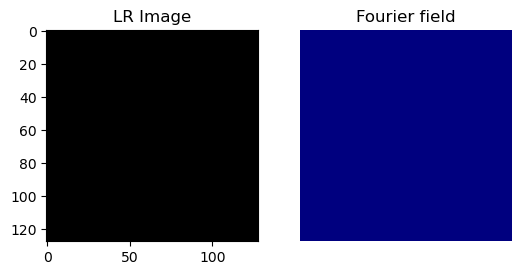

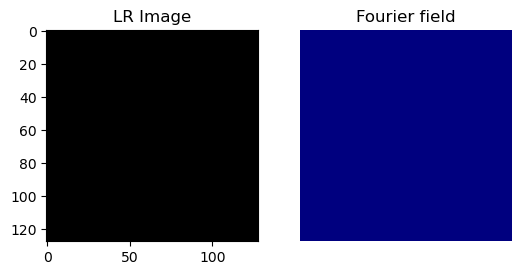

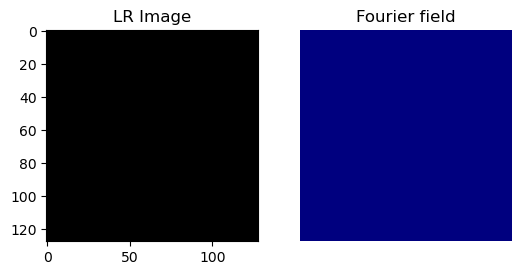

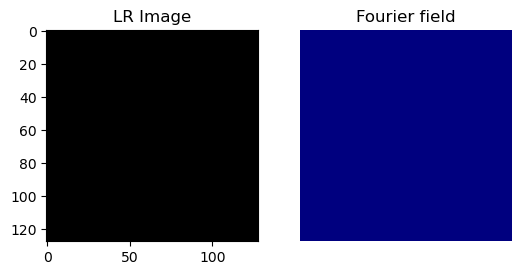

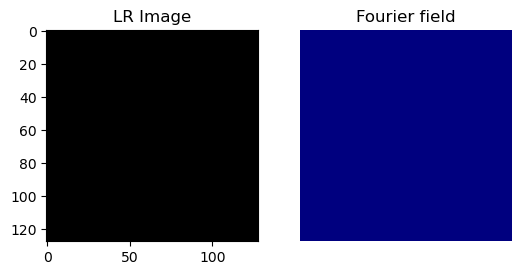

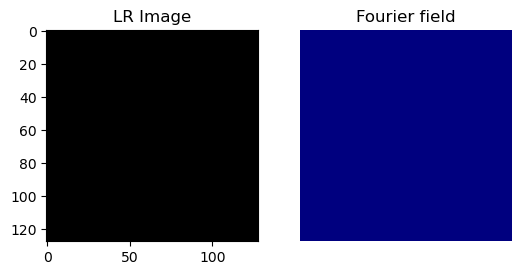

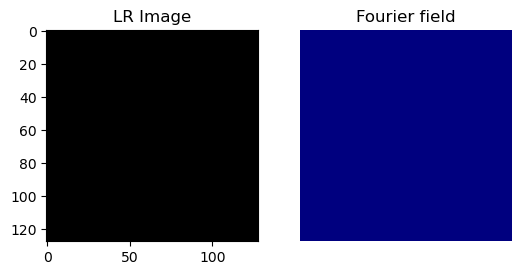

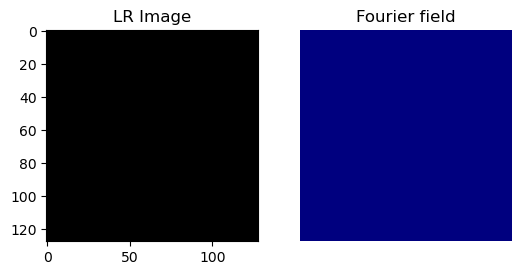

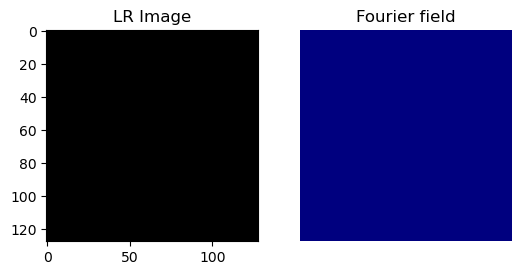

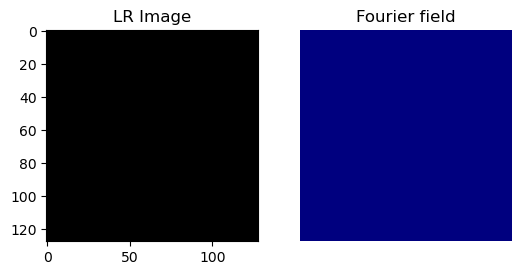

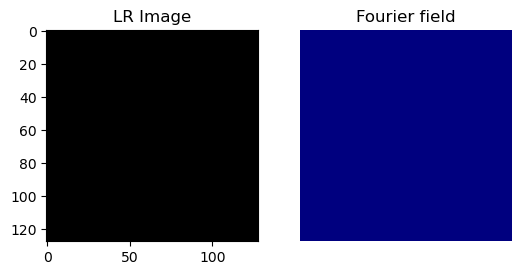

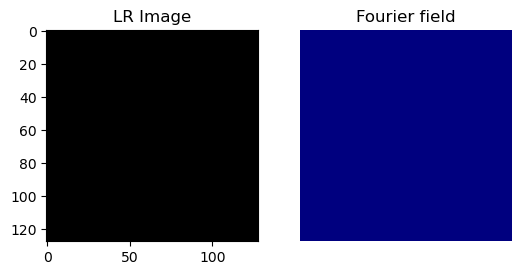

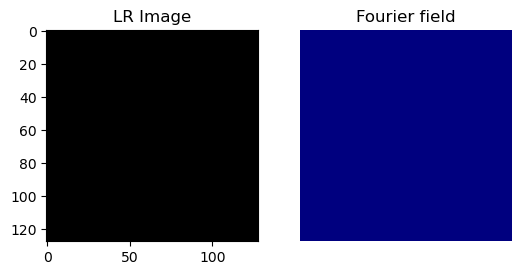

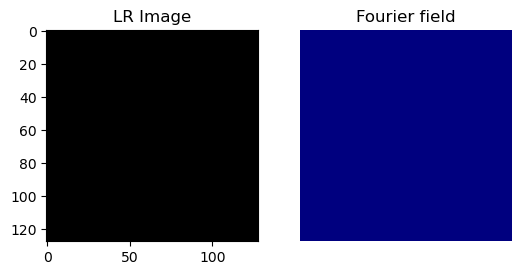

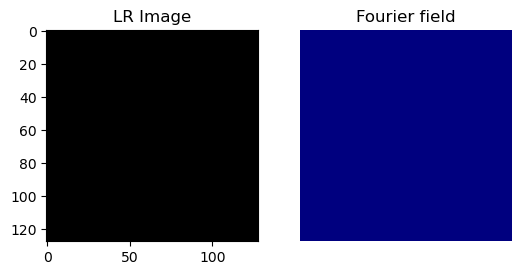

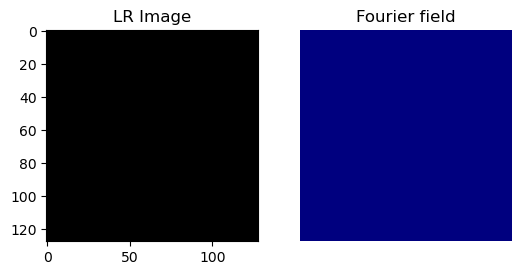

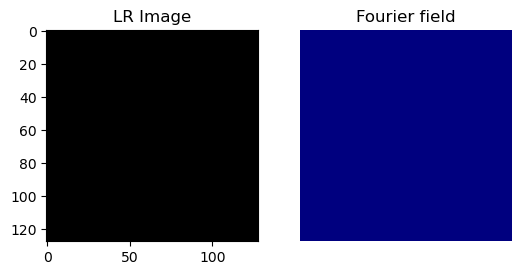

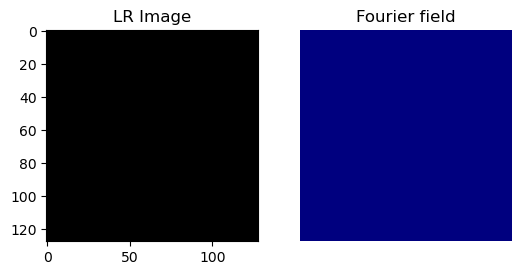

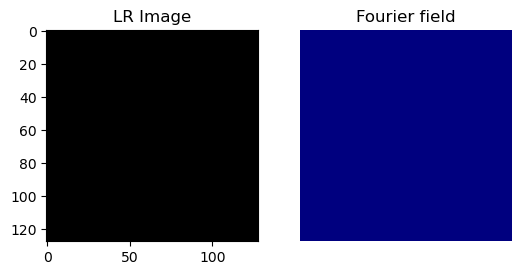

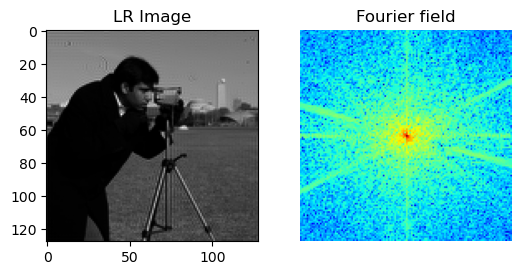

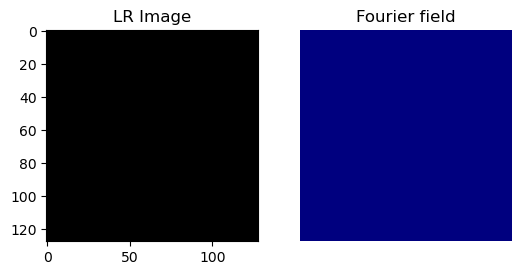

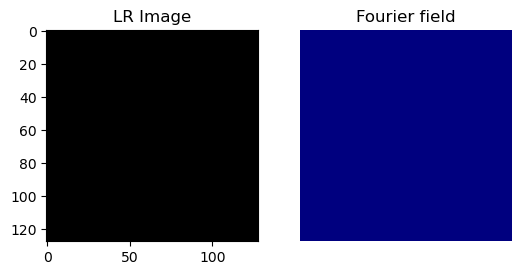

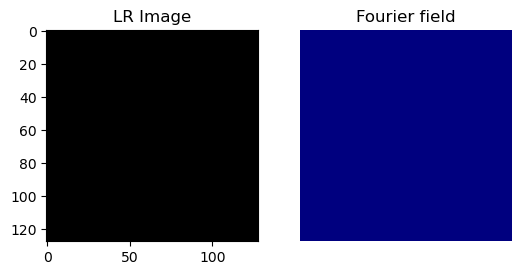

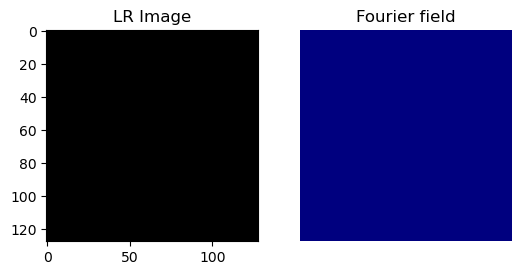

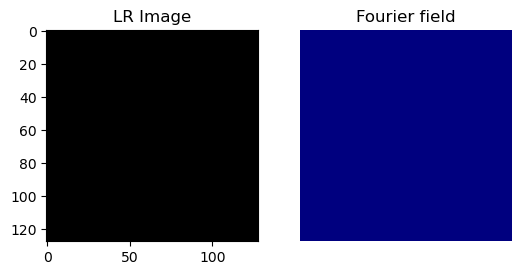

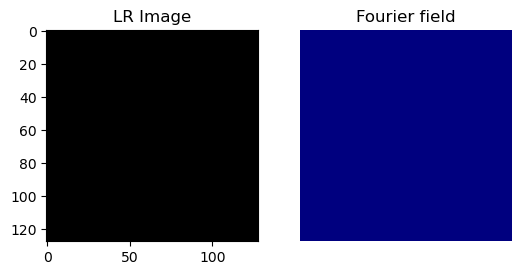

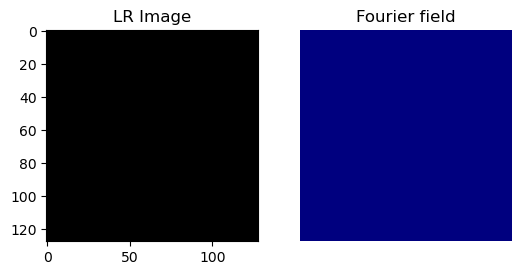

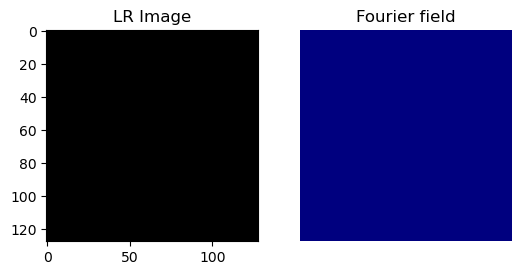

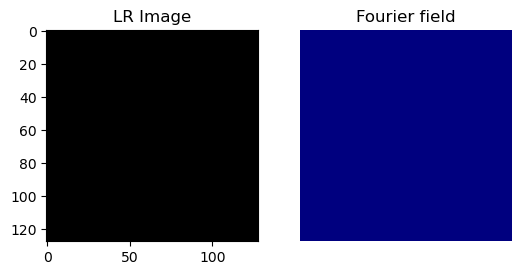

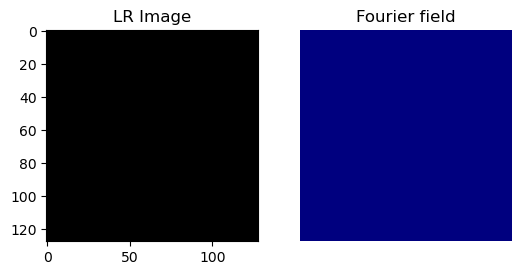

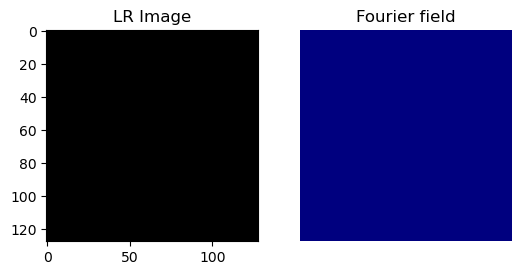

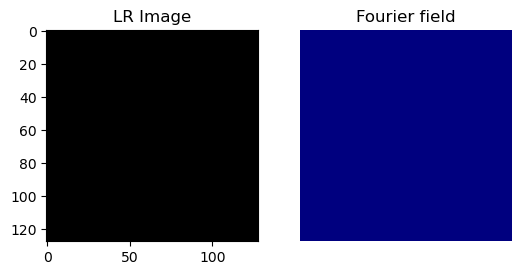

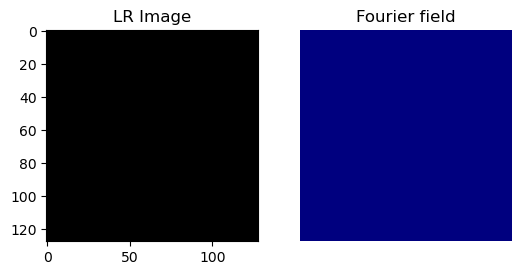

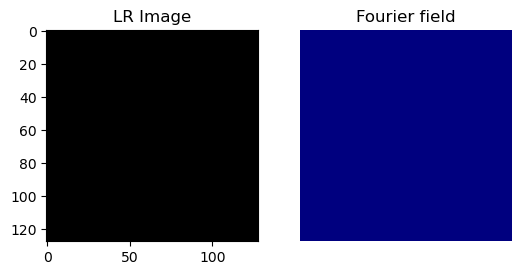

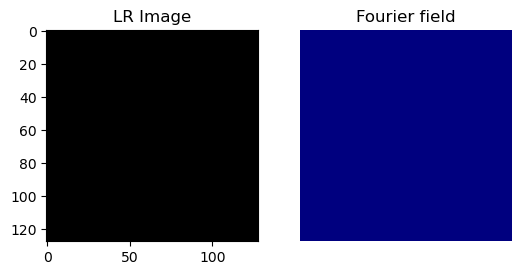

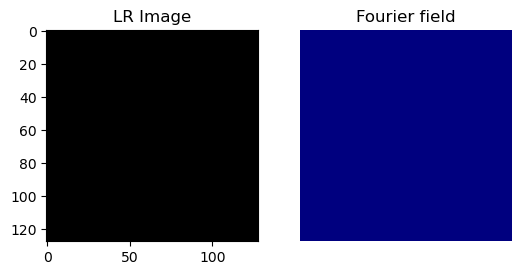

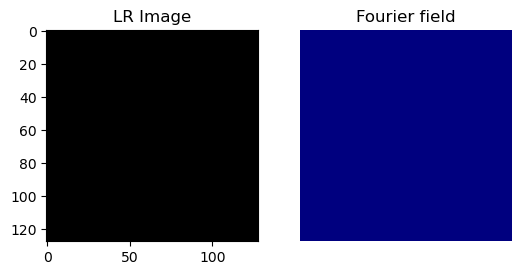

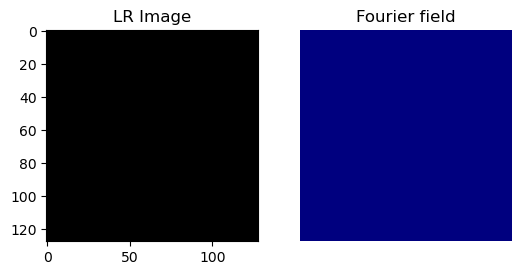

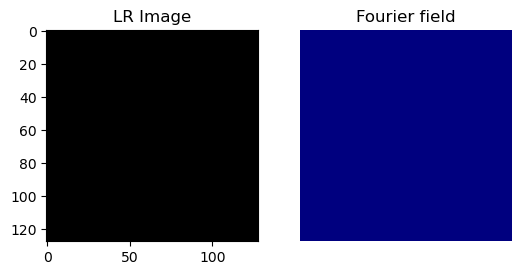

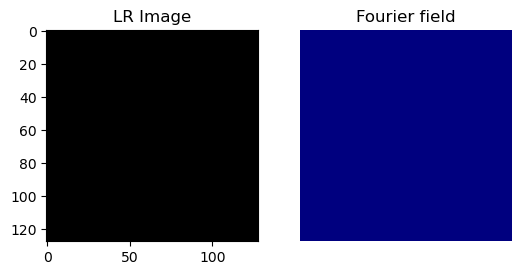

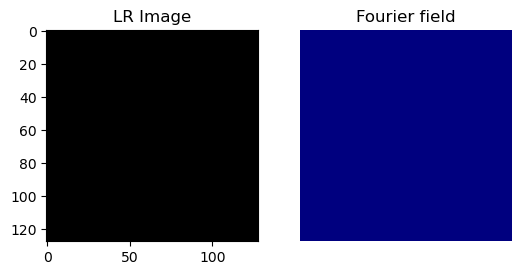

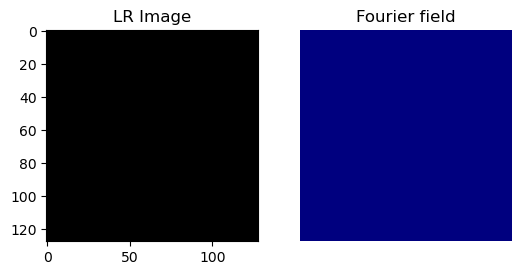

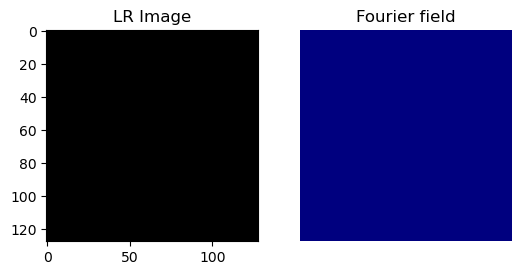

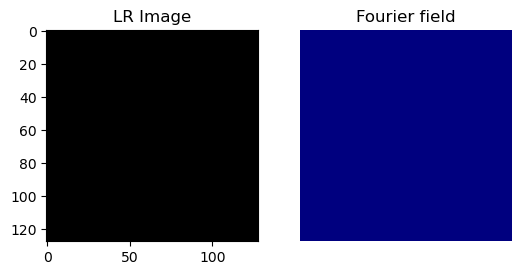

In [76]:
# High-Res frequency space coordinates
df_HR = 1.0 / (N_HR * pixel_size_HR)

# Illumination angles and k-vector shifts
sin_theta_x = x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)
sin_theta_y = y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)

kx_led = -sin_theta_x / wavelength
ky_led = -sin_theta_y / wavelength

# Generate HR Object Spectrum
O_HR = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_true)))

# Store captured Low-Res intensity images
I_measured = np.zeros((array_size, array_size, N_LR, N_LR))

for i in range(array_size):
    for j in range(array_size):
        # Shift of the spectrum in the HR Fourier plane
        shift_x = int(np.round(kx_led[i, j] /df_HR))
        shift_y = int(np.round(ky_led[i, j] /df_HR))
        
        # Define the bounding box for the pupil in the HR spectrum
        # Center of the HR spectrum is N_hr//2
        center_y = N_HR//2 + shift_y
        center_x = N_HR//2 + shift_x
        
        y_start = center_y - N_LR//2
        y_end = center_y + N_LR//2
        x_start = center_x - N_LR//2
        x_end = center_x + N_LR//2
        
        # Extract the shifted spectrum (this mimics the physical downsampling)
        # We add boundary checks in case high-angle LEDs push the pupil outside the HR grid
        if (y_start >= 0 and y_end <= N_HR and x_start >= 0 and x_end <= N_HR):
            O_shifted_crop = O_HR[y_start:y_end, x_start:x_end]
        else:
            # If it falls outside, we pad with zeros (negligible for this simulation size)
            O_shifted_crop = np.zeros((N_LR, N_LR), dtype=np.complex128)
        
        # Multiply by pupil function
        E_LR_fourier = O_shifted_crop * pupil_aberrated
        
        # IFFT to get the complex field at the image plane
        E_LR_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_LR_fourier)))
        
        # Camera captures intensity
        I_measured[i, j, :, :] = np.abs(E_LR_spatial)**2

        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    
        axs[0].imshow(I_measured[i,j], cmap='gray')
        axs[0].set_title("LR Image")
        axs[0].axis('on')
        
        axs[1].imshow(10 * np.log(np.abs(E_LR_fourier)+1), cmap='jet')
        axs[1].set_title('Fourier field')
        axs[1].axis('off')


##### INVERSE MODEL (FPM Reconstruction)

In [77]:
 # Initialize the HR spectrum guess with the central (brightfield) LR image
O_recons = np.zeros((N_HR, N_HR), dtype=np.complex128)
center_idx = array_size // 2

# Use the central LED image, upsampled, as our initial guess
initial_amp = np.sqrt(I_measured[center_idx, center_idx])
E_initial_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
O_recons[N_HR//2 - N_LR//2 : N_HR//2 + N_LR//2, 
        N_HR//2 - N_LR//2 : N_HR//2 + N_LR//2] = E_initial_fourier

iterations = 30
alpha = 1.0 # Step size / relaxation parameter

for iterations in range(iterations):
    # Iterate through all LEDs
    for i in range(array_size):
        for j in range(array_size):
            
            # Identify the region in the HR spectrum
            shift_x = int(np.round(kx_led[i, j] /df_HR))
            shift_y = int(np.round(ky_led[i, j] /df_HR))
            
            center_y = N_HR//2 + shift_y
            center_x = N_HR//2 + shift_x
            
            y_start = center_y - N_LR//2
            y_end = center_y + N_LR//2
            x_start = center_x - N_LR//2
            x_end = center_x + N_LR//2
            
            if (y_start < 0 or y_end > N_HR or x_start < 0 or x_end > N_HR):
                continue # Skip if outside our simulated HR bandwidth bounds
            
            # Extract current guess for this sub-spectrum
            O_patch = O_recons[y_start:y_end, x_start:x_end]
            
            # Apply pupil function to get current LR Fourier guess
            E_est_fourier = O_patch * pupil_aberrated
            
            # IFFT to spatial domain
            E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
            
            #plt.figure()
            #plt.imshow(np.log1p(np.abs(E_est_fourier)), cmap = 'jet')
            #plt.show()
            # Replace amplitude with measured amplitude, keep the phase
            amp_measured = np.sqrt(I_measured[i, j])
            E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
            
            # FFT back to Fourier domain
            E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
            
            # Update the HR spectrum guess (using a standard gradient descent update)
            # We only update where the pupil is non-zero
            pupil_intensity = np.abs(pupil_aberrated)**2
            max_pupil = np.max(pupil_intensity)
            
            update = (np.conj(pupil_aberrated) / max_pupil)* (E_updated_fourier - E_est_fourier)
            O_recons[y_start:y_end, x_start:x_end] = O_recons[y_start:y_end, x_start:x_end] + alpha * update

            #plt.figure()
            #plt.imshow(np.log1p(np.abs(O_recons)), cmap = 'jet')
            #plt.savefig(f"plot_{iterations,i,j}.png", bbox_inches='tight', pad_inches=0)

# Transform reconstructed HR spectrum back to spatial domain
obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recons)))
amp_recon = np.abs(obj_recon_spatial)
phase_recon = np.angle(obj_recon_spatial)


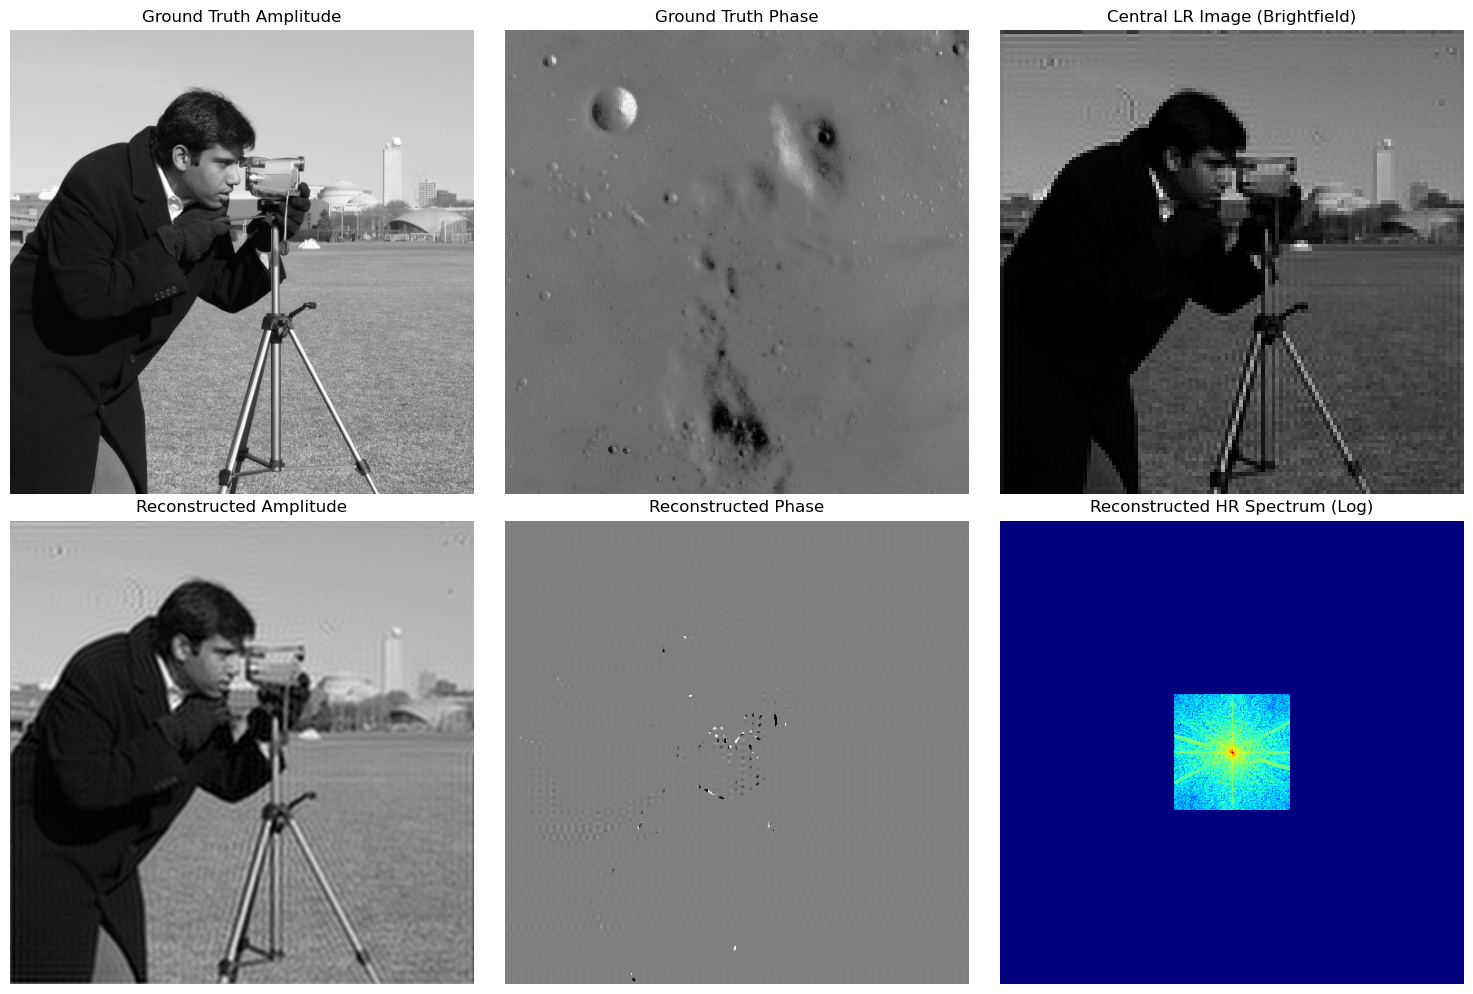

In [78]:
plt.figure(figsize=(15,10))
    
plt.subplot(2, 3, 1)
plt.title("Ground Truth Amplitude")
plt.imshow(amp, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Ground Truth Phase")
plt.imshow(phase, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title(f"Central LR Image (Brightfield)")
plt.imshow(I_measured[center_idx, center_idx], cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Reconstructed Amplitude")
plt.imshow(amp_recon, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Reconstructed Phase")
plt.imshow(phase_recon, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Reconstructed HR Spectrum (Log)")
plt.imshow(np.log1p(np.abs(O_recons)), cmap='jet')
plt.axis('off')

plt.tight_layout()
#plt.savefig('Final_results3.png')
plt.show()


In [79]:
#for i in range(array_size):
#    for j in range(array_size):
#        plt.figure(figsize=(12, 4))
#        plt.axis('off')
#        plt.imshow(I_measured[i,j], cmap='gray')
#        plt.savefig(f"plot_{i,j}.png", bbox_inches='tight', pad_inches=0)